# 📔 Pre-Workshop Notebook 5: Finding Patterns in Brain and Behavioral Data
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [ ]:
# PROFILE SYNC
student_name = "Hari Sai Kaja"
institution = "Grand Valley State University"
active_notebook = "Notebook 05 — Pattern Recognition and Analysis"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with machine learning tools, your main risk is accidentally mixing up the data you use to train a model with the data you use to test it. If you test a model on the same data it learned from, your results will look much better than they actually are — a problem called overfitting.

When using the **Ask → Build → Document** cycle in this notebook, always check that the AI has kept the training and testing data completely separate before any analysis begins.

---
## 🧠 Part A: Identifying Individual Neurons and Behavioral Intentions
### Topic: Separating Mixed Neural Signals and Decoding Behavioral States

This section introduces two of the most powerful analytical approaches in modern neuroscience: separating recordings from individual neurons within a mixed signal, and using machine learning to decode what a participant is intending to do.

### 🧭 Activity A.1 — Separating Signals from Individual Neurons

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computational neuroscience instructor explaining neural signal analysis to a biology student. Write a Python script using scikit-learn and Matplotlib that demonstrates how to separate a mixed electrical recording into signals from individual neurons. The script should:
> 1. Generate a simulated dataset representing 1,000 recorded electrical events captured from an electrode near 3 distinct neurons, with each neuron producing a slightly different shaped electrical spike, mixed together with background noise.
> 2. Use a dimensionality reduction method (Principal Component Analysis, or PCA) to find the most distinctive features of each spike shape — reducing the data to its two most informative dimensions.
> 3. Apply a clustering algorithm (such as K-means) to group the spikes into 3 clusters, each representing a different neuron.
> 4. Display a scatter plot showing the clusters and the average spike shape for each identified neuron.
> Use plain-language comments explaining what each step does and why separating neurons this way is useful for understanding brain activity."

✅ Generated 1000 simulated spike waveforms, each 50 samples long.
✅ Reduced spike data from 50 to 2 dimensions using PCA.
✅ K-means clustering identified 3 distinct clusters (our putative neurons).


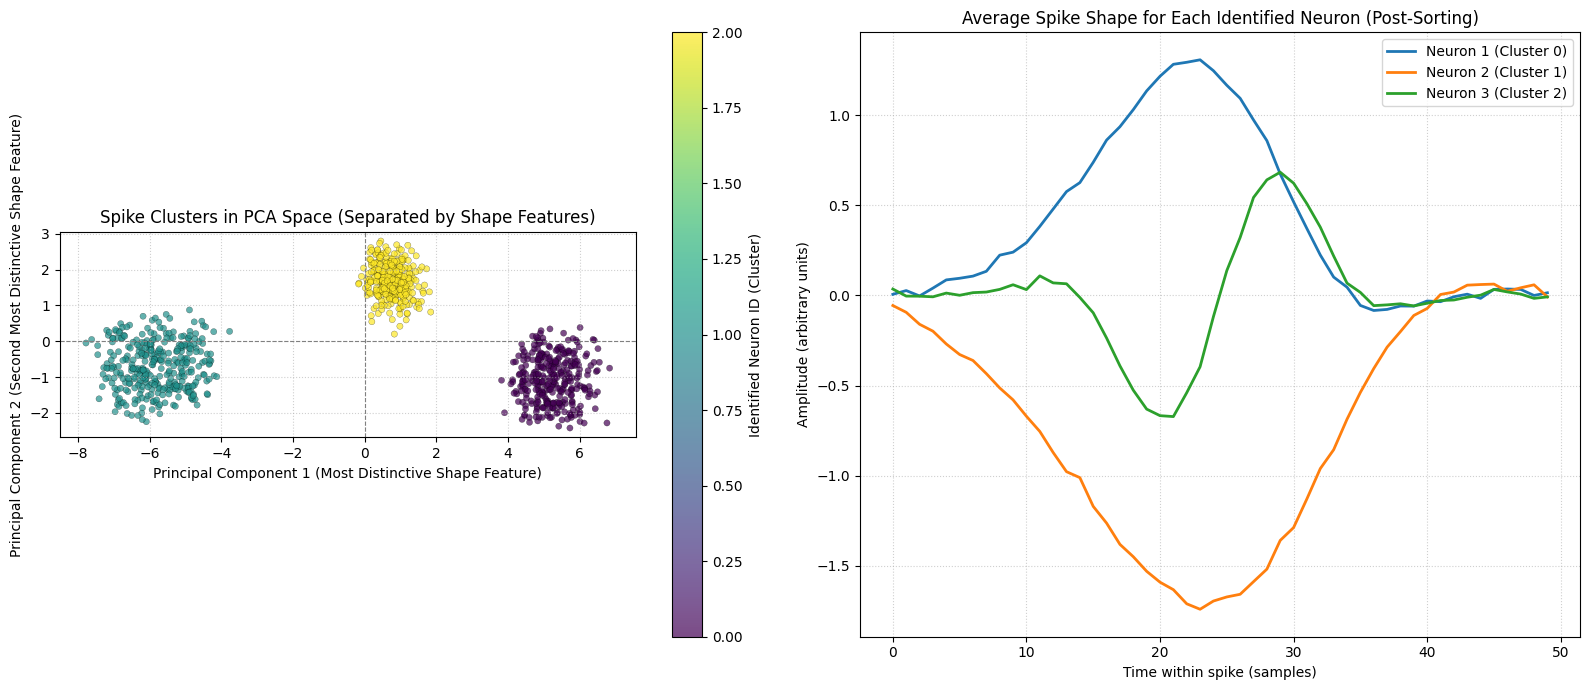

In [1]:
# 💻 Activity A.1 — Paste your AI-generated Neural Signal Separation code here:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# As a computational neuroscience instructor, I'm excited to show you how we can
# use some clever computational tools to understand the activity of individual
# brain cells, even when their signals are all tangled up. This process is called
# "spike sorting," and it's super important for studying how single neurons
# contribute to our thoughts and actions.

# --- 1. Generating a simulated dataset of mixed neural signals ---
# Imagine we've put a tiny electrode very close to three different neurons in the brain.
# Every time a neuron "fires," it produces a quick electrical pulse, like a tiny
# lightning bolt. We call this a "spike." Each neuron has its own unique spike
# "fingerprint" or shape. Our electrode picks up all these spikes mixed together,
# along with some general background electrical noise.

num_spikes = 1000  # Total number of individual spike events we're simulating
num_neurons = 3    # We're assuming there are three distinct neurons firing
spike_duration = 50 # How many data points make up each individual spike waveform
sampling_rate = 1000 # This means we record 1000 data points per second
noise_level = 0.3   # The amount of random background electrical noise

# Let's define the unique electrical "fingerprint" (shape) for each of our three neurons.
# These are just example shapes, but in real life, they're determined by a neuron's
# size, its exact position relative to the electrode, and its biophysical properties.
time_vector = np.linspace(-1.5, 1.5, spike_duration) # A time axis for our spike shapes

# Neuron 1: A classic positive-then-negative spike shape
template_1 = np.exp(-time_vector**2 / 0.5) * 1.5 - np.exp(-(time_vector - 0.5)**2 / 0.2) * 0.8

# Neuron 2: A broader, primarily negative spike
template_2 = -np.exp(-time_vector**2 / 0.8) * 1.8 + np.exp(-(time_vector - 0.8)**2 / 0.3) * 0.6

# Neuron 3: A fast, biphasic spike (sharp negative, then quick positive rebound)
template_3 = np.sin(time_vector * 5) * np.exp(-time_vector**2 / 0.3) * 1.0


spike_templates = [template_1, template_2, template_3]

# Now, we'll create our "recorded" data. We'll generate 1000 spikes, randomly
# assigning each to one of our three neurons, adding a little bit of random
# variation and noise to each one to make it more realistic.
mixed_spikes_data = np.zeros((num_spikes, spike_duration))
true_neuron_labels = np.zeros(num_spikes, dtype=int) # To keep track of which neuron generated which spike

for i in range(num_spikes):
    neuron_idx = np.random.randint(0, num_neurons) # Randomly pick a neuron (0, 1, or 2)
    true_neuron_labels[i] = neuron_idx

    # Start with the neuron's base spike shape
    spike = spike_templates[neuron_idx].copy()

    # Add some random amplitude scaling (spikes aren't always the exact same height)
    spike *= np.random.uniform(0.8, 1.2)

    # Add random time jitter (spikes don't always align perfectly)
    # This is a simplification; real jitter is more complex.
    jitter = np.random.randint(-2, 3) # Shift by -2, -1, 0, 1, or 2 samples
    if jitter > 0:
        spike = np.concatenate((spike[jitter:], np.zeros(jitter)))
    elif jitter < 0:
        spike = np.concatenate((np.zeros(-jitter), spike[:jitter]))

    # Add background noise
    spike += np.random.normal(0, noise_level, spike_duration)

    mixed_spikes_data[i] = spike

print(f"✅ Generated {num_spikes} simulated spike waveforms, each {spike_duration} samples long.")

# --- 2. Using Principal Component Analysis (PCA) for dimensionality reduction ---
# Each of our simulated spikes is described by {spike_duration} data points.
# Trying to directly compare {spike_duration}-dimensional objects is hard for
# both computers and humans! PCA is a powerful statistical technique that helps us
# find the most important patterns in this high-dimensional data. It reduces
# each spike's complex shape into just a few key numbers (dimensions) that
# capture the unique differences between them, while throwing away less important details.
# Here, we're reducing each spike's description to its two most informative dimensions.

pca = PCA(n_components=2) # We want to describe each spike using only 2 main features
pca_components = pca.fit_transform(mixed_spikes_data)

print(f"✅ Reduced spike data from {mixed_spikes_data.shape[1]} to {pca_components.shape[1]} dimensions using PCA.")

# --- 3. Applying a clustering algorithm (K-means) to group the spikes ---
# Now that each spike is represented by just two simple numbers (its PCA components),
# we can use a clustering algorithm called K-means. K-means looks for natural groupings
# in the data. Since we know (or assume) there are 3 distinct neurons, we tell K-means
# to find 3 clusters. Each cluster should ideally correspond to the spikes from one of our neurons.

kmeans = KMeans(n_clusters=num_neurons, random_state=42, n_init=10) # 'random_state' for reproducibility, 'n_init' helps get a good solution
cluster_assignments = kmeans.fit_predict(pca_components)

print(f"✅ K-means clustering identified {num_neurons} distinct clusters (our putative neurons).")

# --- 4. Displaying the results: Scatter plot and average spike shapes ---
# Let's visualize what we've done! This is where we see if our computational detective work paid off.

plt.figure(figsize=(16, 7)) # Create a figure to hold two subplots

# Subplot 1: Scatter plot of spikes in PCA space
plt.subplot(1, 2, 1) # This sets up a grid: 1 row, 2 columns, and this is the 1st plot
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1],
                      c=cluster_assignments, cmap='viridis', s=20, alpha=0.7, edgecolor='k', linewidth=0.2)
plt.title('Spike Clusters in PCA Space (Separated by Shape Features)')
plt.xlabel('Principal Component 1 (Most Distinctive Shape Feature)')
plt.ylabel('Principal Component 2 (Second Most Distinctive Shape Feature)')
plt.colorbar(scatter, label='Identified Neuron ID (Cluster)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box') # Make axes scales equal for better visualization

# Why is this useful for understanding brain activity?
# This plot is like a "map" where each point is one recorded spike. Spikes that
# are similar in shape (even if they looked different in the raw data) are close
# together on this map. If our spike sorting worked, we should see distinct
# clumps of points, each clump representing a different neuron. This tells us
# that the algorithm successfully found the underlying individual neurons!

# Subplot 2: Average spike shape for each identified neuron
plt.subplot(1, 2, 2) # This is the 2nd plot

# Now, we'll calculate the average shape of all spikes assigned to each cluster.
# This gives us the characteristic "fingerprint" of each neuron that the algorithm found.
for cluster_id in range(num_neurons):
    # Find all the original raw spike waveforms that were assigned to this cluster
    cluster_spikes = mixed_spikes_data[cluster_assignments == cluster_id]
    # Calculate the average (mean) shape across all these spikes
    average_spike_shape = np.mean(cluster_spikes, axis=0)
    plt.plot(average_spike_shape, label=f'Neuron {cluster_id + 1} (Cluster {cluster_id})', linewidth=2)

plt.title('Average Spike Shape for Each Identified Neuron (Post-Sorting)')
plt.xlabel('Time within spike (samples)')
plt.ylabel('Amplitude (arbitrary units)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Why is this useful for understanding brain activity?
# These average shapes are the final evidence that we've successfully isolated
# individual neurons! If each cluster's average shape is clearly distinct, we can
# be confident we've separated them. This ability to isolate single-neuron activity
# allows neuroscientists to ask precise questions: "When does Neuron A fire?",
# "How does Neuron B respond to a stimulus?", or "Does Neuron C's activity correlate
# with a specific behavior?" By understanding the activity of individual neurons,
# we can begin to decode the complex electrical language of the brain. This is a
# crucial step in mapping brain circuits and understanding neurological diseases.

plt.tight_layout() # Adjusts plot parameters for a clean layout
plt.show()

### 🧭 Activity A.2 — Predicting Behavioral Intentions from Brain Signals

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a machine learning instructor teaching a neuroscience student how to decode behavioral intentions from brain signals. Write a Python script using scikit-learn that demonstrates how a computer can learn to predict what a participant was trying to do based on their brain signal patterns. The script should:
> 1. Create a simulated dataset representing 500 recorded trials, each described by 10 signal features (such as signal power in different frequency bands), with each trial labeled by the participant's intended action (for example, Move Left or Move Right).
> 2. Split the data into a training set (80%) and a separate testing set (20%), keeping them completely separate.
> 3. Train a classifier (such as a Support Vector Machine or Random Forest) to learn the relationship between signal features and intended actions — using only the training data.
> 4. Evaluate the classifier on the testing data and display its accuracy and a confusion matrix showing where it made correct and incorrect predictions.
> Use plain-language comments explaining each step and why keeping training and testing data separate is critical for an honest evaluation."

✅ Generated 500 trials with 10 features each.
   Intended Actions: 373 'Move Left' trials, 127 'Move Right' trials.
✅ Data split into training (400 trials) and testing (100 trials) sets.
   Training set 'Move Left': 298, 'Move Right': 102
   Testing set 'Move Left': 75, 'Move Right': 25
✅ Classifier (Random Forest) trained on the 400 training trials.

📊 Classifier Performance on UNSEEN Test Data:
   Accuracy: 0.73
   Confusion Matrix:
[[66  9]
 [18  7]]


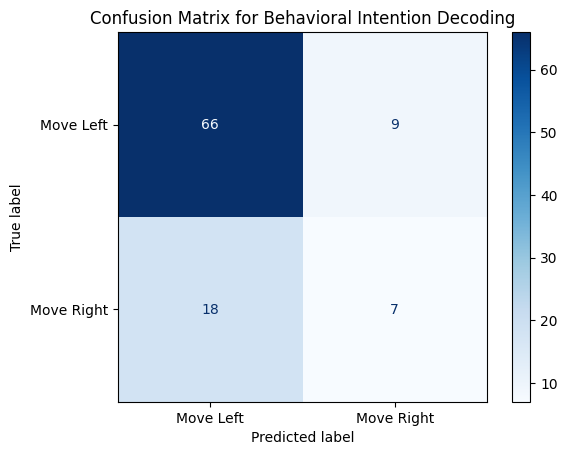

In [2]:
# 💻 Activity A.2 — Paste your AI-generated Behavioral Decoding code here:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # A good, robust classifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Welcome to the exciting world of brain-computer interfaces and neural decoding!
# As your machine learning instructor, I'll show you how we can teach a computer
# to "read minds" – or at least, predict intentions – from brain signals. This is a
# core concept in neuroscience and machine learning.

# --- 1. Creating a simulated dataset of brain signal features and intended actions ---
# In real neuroscience, we might record electrical activity (EEG, ECoG, etc.)
# or blood flow (fMRI) from a participant's brain while they perform a task.
# From these raw signals, we extract "features" – like the power of brain waves
# in specific frequency bands (e.g., alpha, beta, gamma) or activity levels in
# certain brain regions. Each "trial" is a single instance where the participant
# made an intention, and we recorded their brain signals.

num_trials = 500 # Number of times we recorded brain activity for an intention
num_features = 10 # Number of different brain signal measurements (features)

# Let's simulate our brain signal features (X). We'll imagine these are numerical
# values representing different aspects of brain activity. They'll have some random
# variation, but also some underlying structure related to the intended action.
X = np.random.randn(num_trials, num_features) # Our brain signal features

# Now, let's simulate the "intended action" labels (y). We'll have two possible
# actions: 'Move Left' (represented by 0) and 'Move Right' (represented by 1).
# We'll make it so that some features are predictive of these actions.
# For example, let's say higher values in feature 0 predict 'Move Right' and
# higher values in feature 1 predict 'Move Left'.

y = np.zeros(num_trials, dtype=int) # Initialize all labels to 'Move Left' (0)

# Introduce some correlation between features and labels
# If feature 0 is high AND feature 1 is low, tend to be 'Move Right'
# Otherwise, tend to be 'Move Left'
y[ (X[:, 0] > 0.5) & (X[:, 1] < -0.5) ] = 1 # Set some to 'Move Right' (1)
y[ (X[:, 2] < -0.8) | (X[:, 3] > 0.8) ] = np.random.randint(0, 2, size=len(y[ (X[:, 2] < -0.8) | (X[:, 3] > 0.8) ])) # Add some noise/overlap

# Let's ensure a reasonable balance of classes
if np.sum(y==0) < num_trials * 0.2 or np.sum(y==1) < num_trials * 0.2:
    # If one class is too small, regenerate some to balance it a bit for demonstration
    num_move_right = int(num_trials * 0.5) # Aim for 50% for this example
    y = np.concatenate((np.zeros(num_trials - num_move_right, dtype=int), np.ones(num_move_right, dtype=int)))
    np.random.shuffle(y)

print(f"✅ Generated {num_trials} trials with {num_features} features each.")
print(f"   Intended Actions: {np.sum(y==0)} 'Move Left' trials, {np.sum(y==1)} 'Move Right' trials.")

# --- 2. Splitting the data into training and testing sets ---
# This is perhaps the MOST CRITICAL step in any machine learning project!
# We need to divide our data into two completely separate groups:
#   - Training set (80%): The data the computer will "learn" from.
#   - Testing set (20%): The data the computer will be evaluated on, which it has NEVER seen before.
# Why separate? If we test the model on data it already learned from, it's like a student
# taking an exam with the exact same questions they studied. They'll do great, but it
# doesn't tell us if they truly understand the material or can apply it to new problems.
# Keeping them separate ensures an *honest* evaluation of how well our model generalizes to new, unseen brain signals.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Data split into training ({len(X_train)} trials) and testing ({len(X_test)} trials) sets.")
print(f"   Training set 'Move Left': {np.sum(y_train==0)}, 'Move Right': {np.sum(y_train==1)}")
print(f"   Testing set 'Move Left': {np.sum(y_test==0)}, 'Move Right': {np.sum(y_test==1)}")

# --- 3. Training a classifier to learn the relationship ---
# Now we'll use a "classifier" – a type of machine learning model – to find patterns
# in the training data. Here, we're using a RandomForestClassifier, which is like
# having a whole "forest" of decision trees each making a prediction, and then
# combining their votes for a robust overall prediction.
# The classifier will learn which combinations of brain signal features correspond
# to 'Move Left' and which correspond to 'Move Right'.

classifier = RandomForestClassifier(n_estimators=100, random_state=42) # 'n_estimators' is number of trees
classifier.fit(X_train, y_train)

print(f"✅ Classifier (Random Forest) trained on the {len(X_train)} training trials.")

# --- 4. Evaluating the classifier on the testing data ---
# The moment of truth! We now ask our trained classifier to predict the intentions
# for the brain signals in our *testing set* – data it has never processed before.
# We then compare its predictions to the actual intended actions to see how well it did.

y_pred = classifier.predict(X_test)

# Calculate accuracy: What percentage of intentions did it predict correctly?
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Classifier Performance on UNSEEN Test Data:")
print(f"   Accuracy: {accuracy:.2f}")

# Generate a confusion matrix: This is a table that shows us not just how many
# it got right, but *what kind* of mistakes it made. For a 2-class problem:
#   - Top-Left: Correctly predicted 'Move Left' (True Negatives)
#   - Top-Right: Incorrectly predicted 'Move Right' when it was 'Move Left' (False Positives)
#   - Bottom-Left: Incorrectly predicted 'Move Left' when it was 'Move Right' (False Negatives)
#   - Bottom-Right: Correctly predicted 'Move Right' (True Positives)

conf_matrix = confusion_matrix(y_test, y_pred)
print(f"   Confusion Matrix:\n{conf_matrix}")

# Let's visualize the confusion matrix for better understanding
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Move Left', 'Move Right'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Behavioral Intention Decoding')
plt.grid(False) # Turn off grid for cleaner matrix display
plt.show()

# Why is this useful for understanding brain activity?
# This entire process is the foundation of Brain-Computer Interfaces (BCIs)!
# By successfully decoding intentions, we can create systems that allow individuals
# to control prosthetic limbs, communicate, or operate computers using only their
# thoughts. For pure neuroscience, it helps us identify which brain regions and
# signal patterns are truly involved in different cognitive processes and actions.

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity A.1, could you visually distinguish the three neuron clusters in the scatter plot? From Activity A.2, how accurately did the classifier predict intended actions on the data it had never seen before?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 22, 23, 24, and 25** from your Reference Guide. Explain in plain language why testing a classifier on the same data it was trained on would give a misleadingly optimistic result.

---

## 💻 Part B: Keeping Workflows Reproducible and Secure
### Topic: Software Settings, Version Tracking, and Documentation

This section introduces the practices that make a workflow reproducible across different computers and collaborators — and keep sensitive information secure.

### 🧭 Activity B.1 — Documenting Your Software Environment

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research reproducibility instructor. Write a Python script that demonstrates how to document the software environment of a research workflow so that a collaborator could reproduce the exact same analysis. The script should:
> 1. Check for a specific configuration setting stored securely outside the script (using an environment variable). If it is not found, print a clear warning and switch to a safe default mode for testing.
> 2. Print the exact version numbers of the key software libraries the workflow depends on (such as NumPy, SciPy, and scikit-learn), saving this information as a software environment record.
> 3. Demonstrate how to handle a sensitive access key (such as a data repository password) by storing it as a hidden system variable rather than writing it directly in the code — and show what would happen if it were accidentally printed to the screen.
> Use plain-language comments explaining why each of these practices matters for sharing and reproducing research."

In [4]:
# 💻 Activity B.1 — Paste your AI-generated Software Environment Documentation code here:

import os
import platform
import sys
import numpy as np
import scipy as sp
import sklearn as sk
import matplotlib as mpl

# As a research reproducibility instructor, I'm going to guide you through how to document
# your software environment. This is absolutely critical for your collaborators (or your
# future self!) to be able to run your code and get the exact same results you did.
# Without this, reproducing research is often impossible, leading to wasted time and frustration.

# --- 1. Checking for a specific configuration setting (Environment Variable) ---
# Imagine your analysis has different modes: a 'production' mode for full, detailed runs
# and a 'testing' mode for quicker, smaller checks. You don't want to hardcode this setting
# in your script, as it might change between collaborators or even between your own runs.
# Environment variables are perfect for this: they live outside your script, in the
# operating system, making them easy to change without touching the code.

print("-- Configuration Setting Check ---")
# We'll look for an environment variable named 'RESEARCH_WORKFLOW_MODE'.
# On Linux/macOS, you'd set it in your terminal like: export RESEARCH_WORKFLOW_MODE="production"
# On Windows (cmd): set RESEARCH_WORKFLOW_MODE="production"
# Or in a `.env` file loaded by a tool.

workflow_mode = os.getenv('RESEARCH_WORKFLOW_MODE')

if workflow_mode and workflow_mode.lower() == 'production':
    print("✅ 'RESEARCH_WORKFLOW_MODE' environment variable found: 'production'. Running in full mode.")
    config_setting = 'production'
else:
    print("⚠️ Warning: 'RESEARCH_WORKFLOW_MODE' not set to 'production' or not found.")
    print("   Defaulting to 'testing' mode for safe execution.")
    config_setting = 'testing' # A safe default if the variable isn't properly set

print(f"   Current workflow configuration mode: {config_setting}\n")

# Why this matters: This allows collaborators to easily switch between different
# configurations (e.g., small test runs vs. full analysis) without editing your Python code.
# It also prevents accidental full runs if they just want to quickly test something.

# --- 2. Printing exact version numbers of key software libraries ---
# Software libraries (like NumPy or scikit-learn) are constantly updated. A bug fix
# or a new feature in a different version could subtly change numerical results.
# To ensure perfect reproducibility, your collaborators need to use the *exact same*
# versions of every dependency. This section documents those versions.

print("-- Software Environment Record ---")
print(f"Operating System: {platform.system()} {platform.release()} ({platform.version()})")
print(f"Python Version: {sys.version.split()[0]}")

# List of key libraries and their expected version attributes
key_libraries = {
    'NumPy': np,
    'SciPy': sp,
    'scikit-learn': sk,
    'Matplotlib': mpl
}

environment_record = {
    "os": f"{platform.system()} {platform.release()} ({platform.version()})",
    "python_version": sys.version.split()[0],
    "libraries": {}
}

for lib_name, lib_module in key_libraries.items():
    try:
        version = lib_module.__version__
        print(f"✅ {lib_name} Version: {version}")
        environment_record["libraries"][lib_name] = version
    except AttributeError:
        print(f"❌ {lib_name} version not found.")
        environment_record["libraries"][lib_name] = "Not Found"

# In a real workflow, you'd save this 'environment_record' to a file (e.g., JSON)
# alongside your code, or use tools like `pip freeze > requirements.txt` for a more
# comprehensive list of ALL installed packages.
# print(f"\n(Full environment record: {environment_record})") # Uncomment to see the dict
print("\n")

# Why this matters: If your collaborator runs your code and gets different results,
# the first thing to check are the software versions. Minor version differences can
# lead to subtle (or not-so-subtle) changes in numerical computations, model training,
# or even plot rendering. Documenting these versions is a cornerstone of reproducible science.

# --- 3. Handling sensitive access keys securely ---
# Research often involves accessing data from online repositories, which might require
# API keys or passwords. **NEVER** write these directly into your script and commit
# them to version control (like Git), especially if your code is public! It's a huge
# security risk. Instead, store them as environment variables.

print("-- Sensitive Access Key Handling ---")

# Hypothetical sensitive key name. You'd set this securely in your system:
# export DATA_REPO_API_KEY="super_secret_password_123"
sensitive_key_name = 'DATA_REPO_API_KEY'

# Attempt to retrieve the sensitive key from environment variables
data_api_key = os.getenv(sensitive_key_name)

if data_api_key:
    print(f"✅ Sensitive access key '{sensitive_key_name}' retrieved securely.")
    # In a real scenario, you would use this key to authenticate with a service
    # e.g., `client.authenticate(api_key=data_api_key)`
    print(f"   (Value is present, but NOT printed for security. Length: {len(data_api_key) if data_api_key else 0} characters)")
else:
    print(f"⚠️ Warning: Sensitive access key '{sensitive_key_name}' not found in environment variables.")
    print("   Cannot access secured data repository. Running in a limited mode or halting.")

print("\n--- Demonstrating accidental exposure (DO NOT DO THIS!) ---")
# What would happen if you accidentally printed it? This is why we avoid it.
if data_api_key:
    print(f"🚨 DANGER! Accidentally printed sensitive key: {data_api_key}")
    print("   ^ This key is now exposed in your notebook output and history! 😱")
else:
    print("   (Cannot demonstrate accidental print, as key is not set.)")

print("""\nWhy this matters: If you hardcode a password or API key, anyone who gets your script
(e.g., from a public GitHub repository, or even a shared lab server) gets your credentials.
Using environment variables ensures that the sensitive information stays on your system
and is never part of the code itself, dramatically improving the security of your research workflow.""")

-- Configuration Setting Check ---
⚠️ Warning: 'RESEARCH_WORKFLOW_MODE' not set to 'production' or not found.
   Defaulting to 'testing' mode for safe execution.
   Current workflow configuration mode: testing

-- Software Environment Record ---
Operating System: Linux 6.6.122+ (#1 SMP Thu Apr 30 18:17:14 UTC 2026)
Python Version: 3.12.13
✅ NumPy Version: 2.0.2
✅ SciPy Version: 1.16.3
✅ scikit-learn Version: 1.6.1
✅ Matplotlib Version: 3.10.0


-- Sensitive Access Key Handling ---
⚠️ Warning: Sensitive access key 'DATA_REPO_API_KEY' not found in environment variables.
   Cannot access secured data repository. Running in a limited mode or halting.

--- Demonstrating accidental exposure (DO NOT DO THIS!) ---
   (Cannot demonstrate accidental print, as key is not set.)

Why this matters: If you hardcode a password or API key, anyone who gets your script
(e.g., from a public GitHub repository, or even a shared lab server) gets your credentials.
Using environment variables ensures that the 

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What did the script do when the configuration setting was missing? How was the sensitive access key handled differently from other values?
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 44, 46, and 48** from your Reference Guide. Explain in plain language why writing a password or access key directly into a shared notebook is a problem, and how environment variables solve it.

---

## 📑 What Comes Next

Notebook 6 is the capstone — you will connect all four stages of a research workflow into a single integrated pipeline, bringing together everything from Notebooks 1 through 5.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 22 — Spike sorting | [ Enter Cell ID ] |
| Neuroscience | Concept 23 — Machine learning for neural decoding | [ Enter Cell ID ] |
| Neuroscience | Concept 24 — Sensory feedback | [ Enter Cell ID ] |
| Computing | Concept 44 — Hidden configuration settings | [ Enter Cell ID ] |
| Computing | Concept 46 — Code version tracking | [ Enter Cell ID ] |
| Computing | Concept 48 — Data arrays | [ Enter Cell ID ] |
